In [1]:
import os
import sys
import numpy as np
import xarray as xr
import geopandas as gpd
import shapely.vectorized as sv
import seaborn as sns

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

import sys
sys.path.append(os.path.abspath("../.."))
from function import DOWN_raw
from function import ART_downscale

In [2]:
beta_version = 'beta_v2'
gamma_version = 'gamma_v2'

npix = 3

In [3]:
# ITALY
lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'

In [4]:
# product, time_reso = 'IMERG', '1dy'
# product, time_reso = 'CMORPH', '3h'
# product, time_reso = 'MSWEP', '3h'
# product, time_reso = 'ERA5', '3h'
product, time_reso = 'GSMaP', '3h'
# product, time_reso = 'CHIRPS', '1dy'

In [5]:
if area == 'PADOVA':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Padova.geojson'))
elif area == 'VENETO':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Veneto.geojson'))
elif area == 'ITALY':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Italy_simple.geojson'))
else:
    sys.exit("Area not recognized. Please choose 'VENETO' or 'ITALY'.")

GEOMETRY_union = GEOMETRY.union_all()

In [6]:
dir_data = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','2_MEV')

dir_file = os.path.join(dir_data,'uncorrected','quantiles_v1',f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc')
DATA_parameters = xr.open_dataset(dir_file)

MEVD_old = DATA_parameters.Mev_d.values

In [7]:
dir_base = os.path.join('..','..','output')

In [8]:
## Gamma
data_dir = os.path.join(dir_base,'Gamma',gamma_version,f'{area}_gamma_{product}_{time_reso}_2002_2023_npix_{npix}.nc')
DATA = xr.open_dataset(data_dir)

lons, lats = DATA.lon.values, DATA.lat.values
lon2d, lat2d = np.meshgrid(lons, lats)

GAMMA = DATA.GAMMA.values

mask_vals = np.isnan(GAMMA)

In [9]:
## Beta
data_dir = os.path.join(dir_base,'Beta',beta_version,f'{area}_Beta_{product}_{time_reso}_2002_2023_npix_{npix}.nc')
DATA = xr.open_dataset(data_dir)

# Cut with the final study area
DATA = DATA.sel(
    lat=slice(DATA_parameters.lat.min(), DATA_parameters.lat.max()),
    lon=slice(DATA_parameters.lon.min(), DATA_parameters.lon.max()))

BETA = DATA.BETA.values

BETA[mask_vals] = np.nan

Text(1.0, 1.0, 'GSMaP')

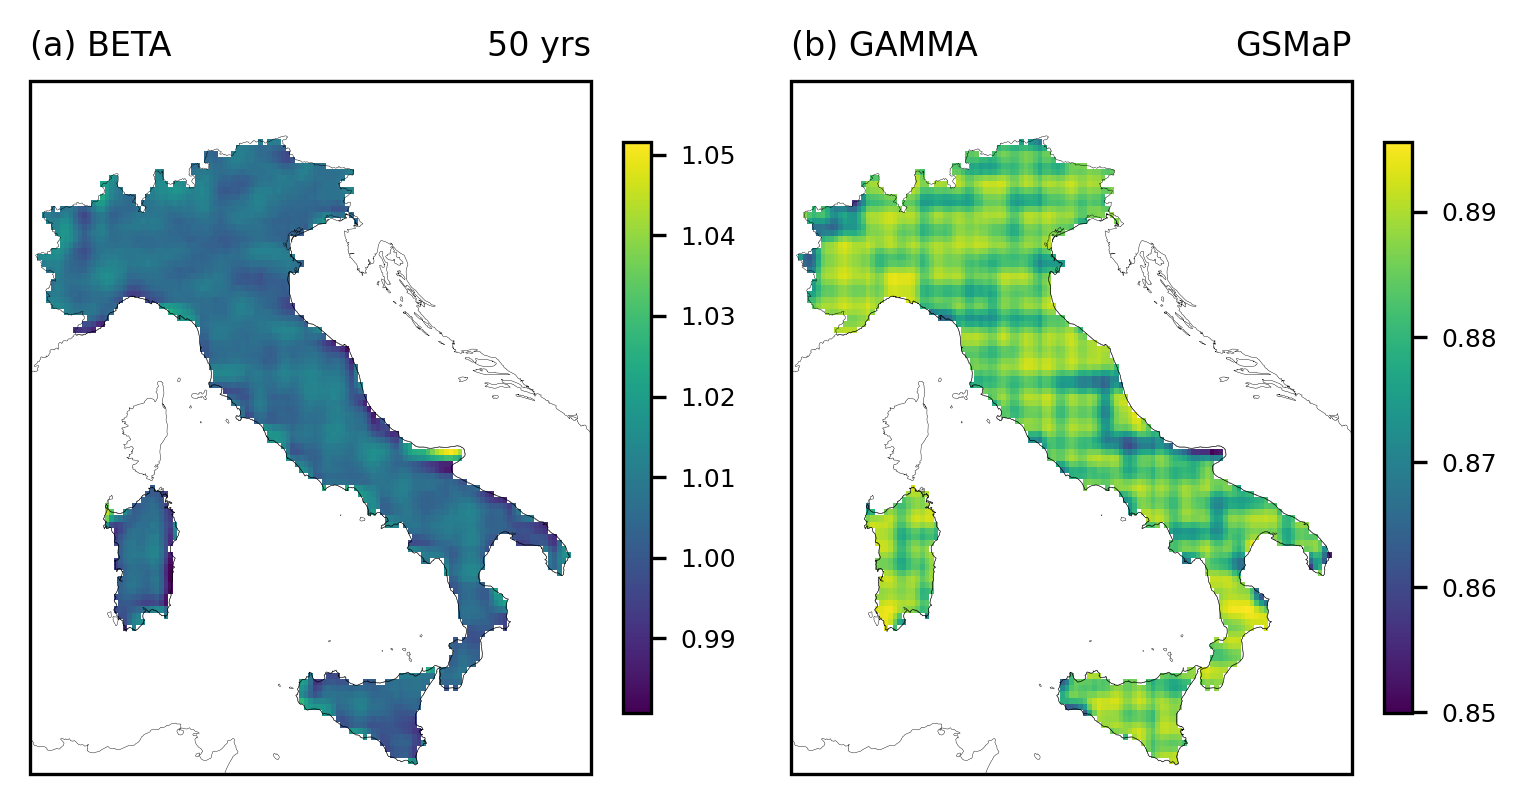

In [10]:
pos = 3

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(6,3),dpi=300)
gs = gridspec.GridSpec(1,2)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, BETA, norm=None, cmap=None)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(a) BETA', fontsize=8, loc='left')
ax1.set_title('50 yrs', fontsize=8, loc='right')

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, GAMMA, norm=None, cmap=None)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(b) GAMMA', fontsize=8, loc='left')
ax1.set_title(product, fontsize=8, loc='right')

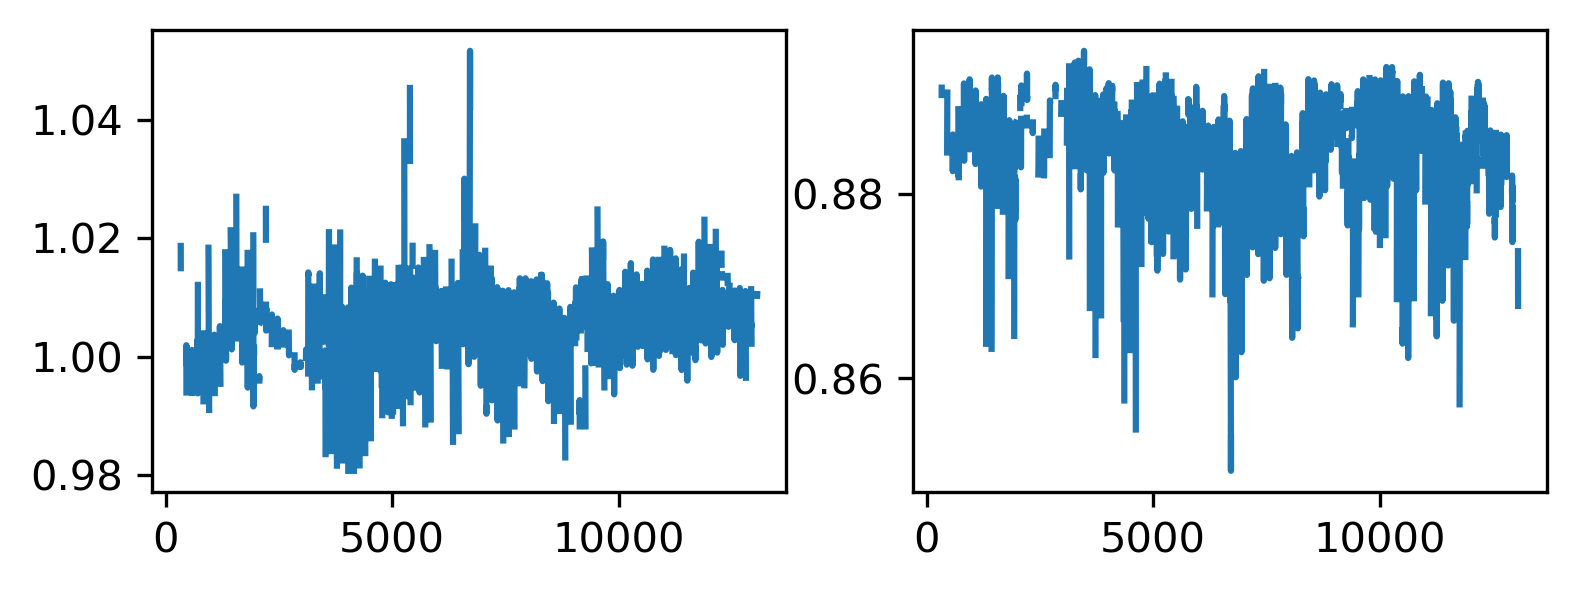

In [11]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(6,2),dpi=300)
gs = gridspec.GridSpec(1,2)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0])
ax1.plot(BETA.flatten())

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1])
ax1.plot(GAMMA.flatten())

Text(0.5, 0, 'Gamma values')

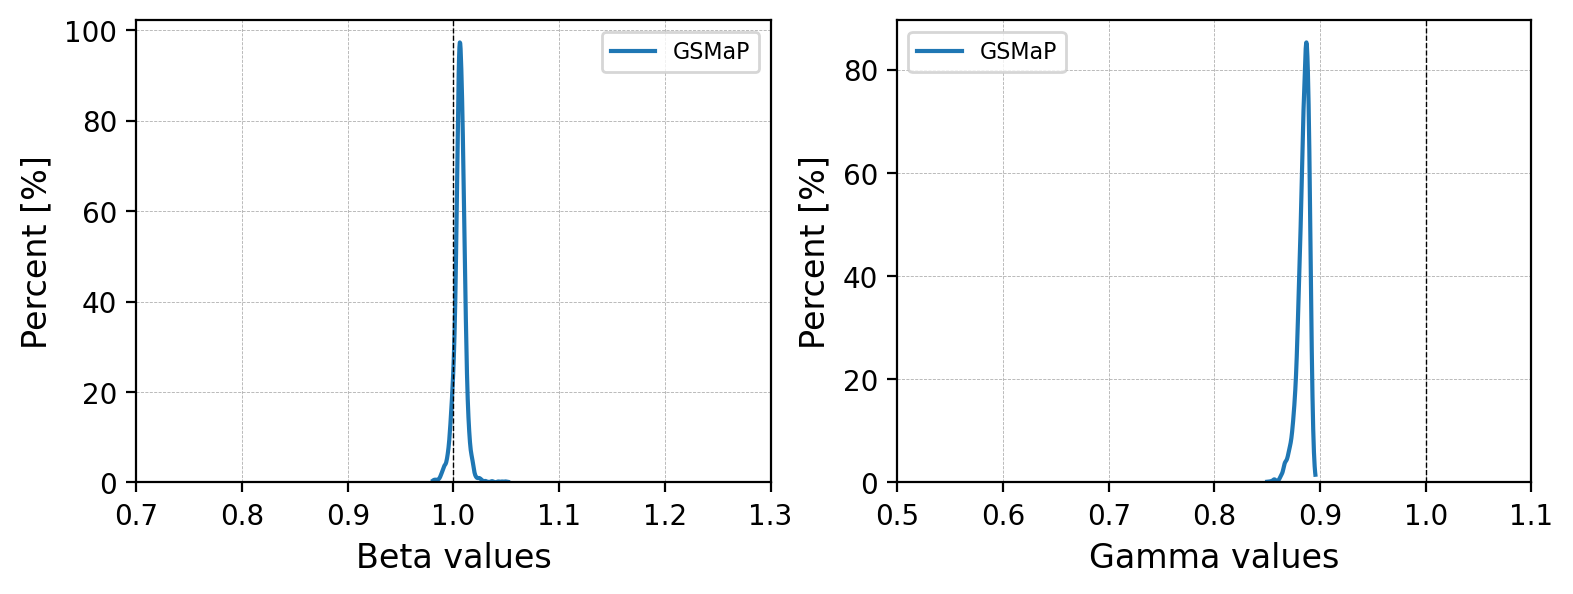

In [12]:
BETA_list =BETA[~np.isnan(BETA)]
GAMMA_list = GAMMA[~np.isnan(GAMMA)]

fig = plt.figure(figsize=(9,3),dpi=200)
gs = gridspec.GridSpec(1,2)

# ==========================================================================================================================
ax1 = plt.subplot(gs[0, 0])

sns.kdeplot(BETA_list,cumulative=False,fill=False,multiple="stack",ax=ax1,label=product,
            clip=(np.nanmin(np.array(BETA_list)), np.nanmax(np.array(BETA_list))))
ax1.axvline(x=1, color='k', linestyle='--', linewidth=  0.5)

ax1.legend(fontsize=8, loc=0, ncol=1)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_xlim(0.7, 1.3)
ax1.set_ylabel('Percent [%]',fontsize=12)
ax1.set_xlabel('Beta values',fontsize=12)

# ==========================================================================================================================
ax1 = plt.subplot(gs[0, 1])

sns.kdeplot(GAMMA_list,cumulative=False,fill=False,multiple="stack",ax=ax1,label=product,
            clip=(np.nanmin(np.array(GAMMA_list)), np.nanmax(np.array(GAMMA_list))))
ax1.axvline(x=1, color='k', linestyle='--', linewidth=  0.5)

ax1.legend(fontsize=8, loc=0, ncol=1)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_xlim(0.5, 1.1)
ax1.set_ylabel('Percent [%]',fontsize=12)
ax1.set_xlabel('Gamma values',fontsize=12)

In [13]:
Tr = [5,  10,  20,  50, 100, 200]
Fi = 1 - 1/np.array(Tr)

NYd = np.zeros(DATA_parameters.NYs.shape)
CYd = np.zeros(DATA_parameters.NYs.shape)
WYd = np.zeros(DATA_parameters.NYs.shape)
MEVD = np.zeros([6, len(lats), len(lons)])

for i in range(len(lats)):
    for j in range(len(lons)):

        Ns = DATA_parameters.NYs.values[:,i,j]
        Cs = DATA_parameters.CYs.values[:,i,j]
        Ws = DATA_parameters.WYs.values[:,i,j]

        bet = BETA[i,j]
        gam = GAMMA[i,j]

        if np.isnan(bet) == True:
            NYd[:,i,j] = np.nan
            CYd[:,i,j] = np.nan
            WYd[:,i,j] = np.nan
            MEVD[:,i,j] = np.nan
        else:
            Nd, Cd, Wd = ART_downscale.down_wei_beta_alpha_update_v2(Ns, Cs, Ws, bet, gam)
            NYd[:,i,j] = Nd
            CYd[:,i,j] = Cd
            WYd[:,i,j] = Wd
            
            x0 = 5.0*np.mean(Cd)
            Mev_d_man, _ = ART_downscale.mev_quant_update(Fi, x0, Nd, Cd, Wd)
            MEVD[:,i,j] = Mev_d_man

/home/arturo/github/MEVD-downscaling/function/ART_downscale.py:744: RuntimeWarning: overflow encountered in square
  wpfun = lambda w: (2*w*gamma(2 / w)/(gamma(1/w))**2) - rhs
/home/arturo/github/MEVD-downscaling/function/ART_downscale.py:744: RuntimeWarning: invalid value encountered in divide
  wpfun = lambda w: (2*w*gamma(2 / w)/(gamma(1/w))**2) - rhs


/home/arturo/github/MEVD-downscaling/function/ART_downscale.py:782: RuntimeWarning: invalid value encountered in power
  mev0f = np.sum( ( 1-np.exp(-(y/C)**W ))**N) - nyears*pr


In [14]:
MEVD_cmap = plt.cm.Spectral_r
MEVD_levels = np.arange(20, 380, 20)
MEVD_norm = mcolors.BoundaryNorm(boundaries=MEVD_levels, ncolors=MEVD_cmap.N, extend='max')

DIFF_cmap = plt.cm.bwr_r
DIFF_levels = np.arange(-30, 35, 5)
DIFF_norm = mcolors.BoundaryNorm(boundaries=DIFF_levels, ncolors=DIFF_cmap.N, extend='both')

In [15]:
MEVD_old[:,mask_vals] = np.nan
MEVD[:,mask_vals] = np.nan

In [16]:
if product == 'CHIRPS':
    ny,nx = np.where(MEVD[3,:,:]>1000)
    MEVD[3:,124,147] = MEVD_old[3:,124,147]
    MEVD[3:,128,154] = MEVD_old[3:,128,154]

Text(0.0, 1.0, '(c) Quantiles Old - New')

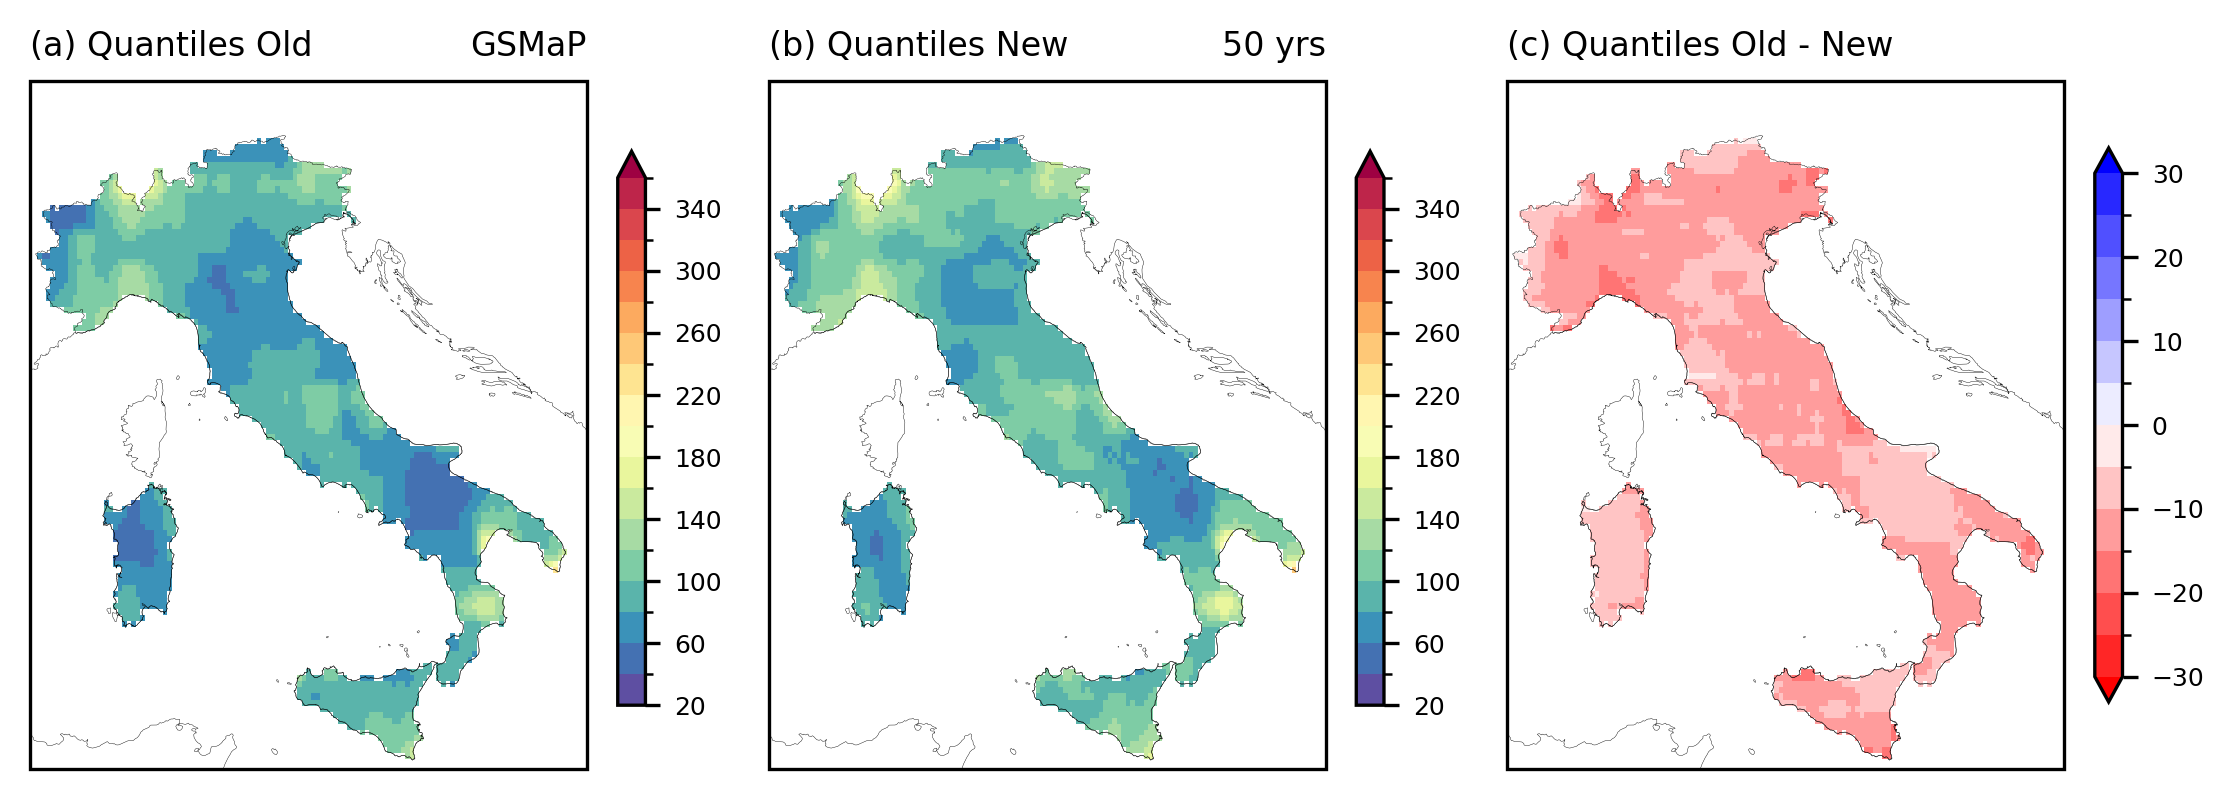

In [17]:
pos = 3

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(9,3),dpi=300)
gs = gridspec.GridSpec(1,3)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, MEVD_old[pos,:,:], norm=MEVD_norm, cmap=MEVD_cmap)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(a) Quantiles Old', fontsize=8, loc='left')
ax1.set_title(product, fontsize=8, loc='right')

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, MEVD[pos,:,:], norm=MEVD_norm, cmap=MEVD_cmap)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(b) Quantiles New', fontsize=8, loc='left')
ax1.set_title('50 yrs', fontsize=8, loc='right')

# ========================================================================================================
ax1 = plt.subplot(gs[0, 2], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, MEVD_old[pos,:,:] - MEVD[pos,:,:], norm=DIFF_norm, cmap=DIFF_cmap)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(c) Quantiles Old - New', fontsize=8, loc='left')

In [18]:
MEVS = DATA_parameters.Mev_s.values
MEVS_masked = np.where(np.isnan(MEVD), np.nan, MEVS)

In [19]:
mask_param = ~np.isnan(MEVD[0, :, :])

NYs_masked = np.where(mask_param[None, :, :], DATA_parameters.NYs.values, np.nan)
CYs_masked = np.where(mask_param[None, :, :], DATA_parameters.CYs.values, np.nan)
WYs_masked = np.where(mask_param[None, :, :], DATA_parameters.WYs.values, np.nan)

NYd_masked = np.where(mask_param[None, :, :], NYd, np.nan)
CYd_masked = np.where(mask_param[None, :, :], CYd, np.nan)
WYd_masked = np.where(mask_param[None, :, :], WYd, np.nan)

In [20]:
desc = DATA_parameters.description.replace('\n', ' ')
desc = ' '.join(DATA_parameters.description.split())

DOWN_xr = xr.Dataset(data_vars={
                    "NYs": (("year","lat","lon"), NYs_masked),
                    "CYs": (("year","lat","lon"), CYs_masked),
                    "WYs": (("year","lat","lon"), WYs_masked),
                    "Mev_s": (("Tr","lat","lon"), MEVS_masked),
                    "NYd": (("year","lat","lon"), NYd_masked),
                    "CYd": (("year","lat","lon"), CYd_masked),
                    "WYd": (("year","lat","lon"), WYd_masked),
                    "Mev_d": (("Tr","lat","lon"), MEVD),
                    "BETA": (("lat","lon"), BETA),
                    "GAMMA": (("lat","lon"), GAMMA),
                    },
    coords={'year':DATA_parameters.year.values,'Tr':Tr,'lat': lats, 'lon': lons},
    attrs=dict(description=desc))

DOWN_xr.NYs.attrs["units"] = "day"
DOWN_xr.NYs.attrs["long_name"] = "Number of wet days"
DOWN_xr.NYs.attrs["origname"] = "Wet days"

DOWN_xr.CYs.attrs["units"] = "dimensionless"
DOWN_xr.CYs.attrs["long_name"] = "Weibull scale parameter"
DOWN_xr.CYs.attrs["origname"] = "Scale"

DOWN_xr.WYs.attrs["units"] = "dimensionless"
DOWN_xr.WYs.attrs["long_name"] = "Weibull shape parameter"
DOWN_xr.WYs.attrs["origname"] = "Shape"

DOWN_xr.Mev_s.attrs["units"] = "mm/day"
DOWN_xr.Mev_s.attrs["long_name"] = "Satellite Maximum Annual Daily"
DOWN_xr.Mev_s.attrs["origname"] = "Satellite quantiles"

DOWN_xr.NYd.attrs["units"] = "day"
DOWN_xr.NYd.attrs["long_name"] = "Downscale Number of wet days"
DOWN_xr.NYd.attrs["origname"] = "Down wet days"

DOWN_xr.CYd.attrs["units"] = "dimensionless"
DOWN_xr.CYd.attrs["long_name"] = "Downscale Weibull scale parameter"
DOWN_xr.CYd.attrs["origname"] = "Down scale"

DOWN_xr.WYd.attrs["units"] = "dimensionless"
DOWN_xr.WYd.attrs["long_name"] = "Downscale Weibull shape parameter"
DOWN_xr.WYd.attrs["origname"] = "Down shape"

DOWN_xr.Mev_d.attrs["units"] = "mm/day"
DOWN_xr.Mev_d.attrs["long_name"] = "Downscaling Maximum Annual Daily"
DOWN_xr.Mev_d.attrs["origname"] = "Downscaling quantiles"

DOWN_xr.BETA.attrs["units"] = "dimensionless"
DOWN_xr.BETA.attrs["long_name"] = "Itermittency function between two generic scales"
DOWN_xr.BETA.attrs["origname"] = "Beta"

DOWN_xr.GAMMA.attrs["units"] = "dimensionless"
DOWN_xr.GAMMA.attrs["long_name"] = "Variance function between two generic scales"
DOWN_xr.GAMMA.attrs["origname"] = "Gamma"

DOWN_xr.lat.attrs["units"] = "degrees_north"
DOWN_xr.lat.attrs["long_name"] = "Latitude"

DOWN_xr.lon.attrs["units"] = "degrees_east"
DOWN_xr.lon.attrs["long_name"] = "Longitude"

Text(0.0, 1.0, '(c) Quantiles Old - New')

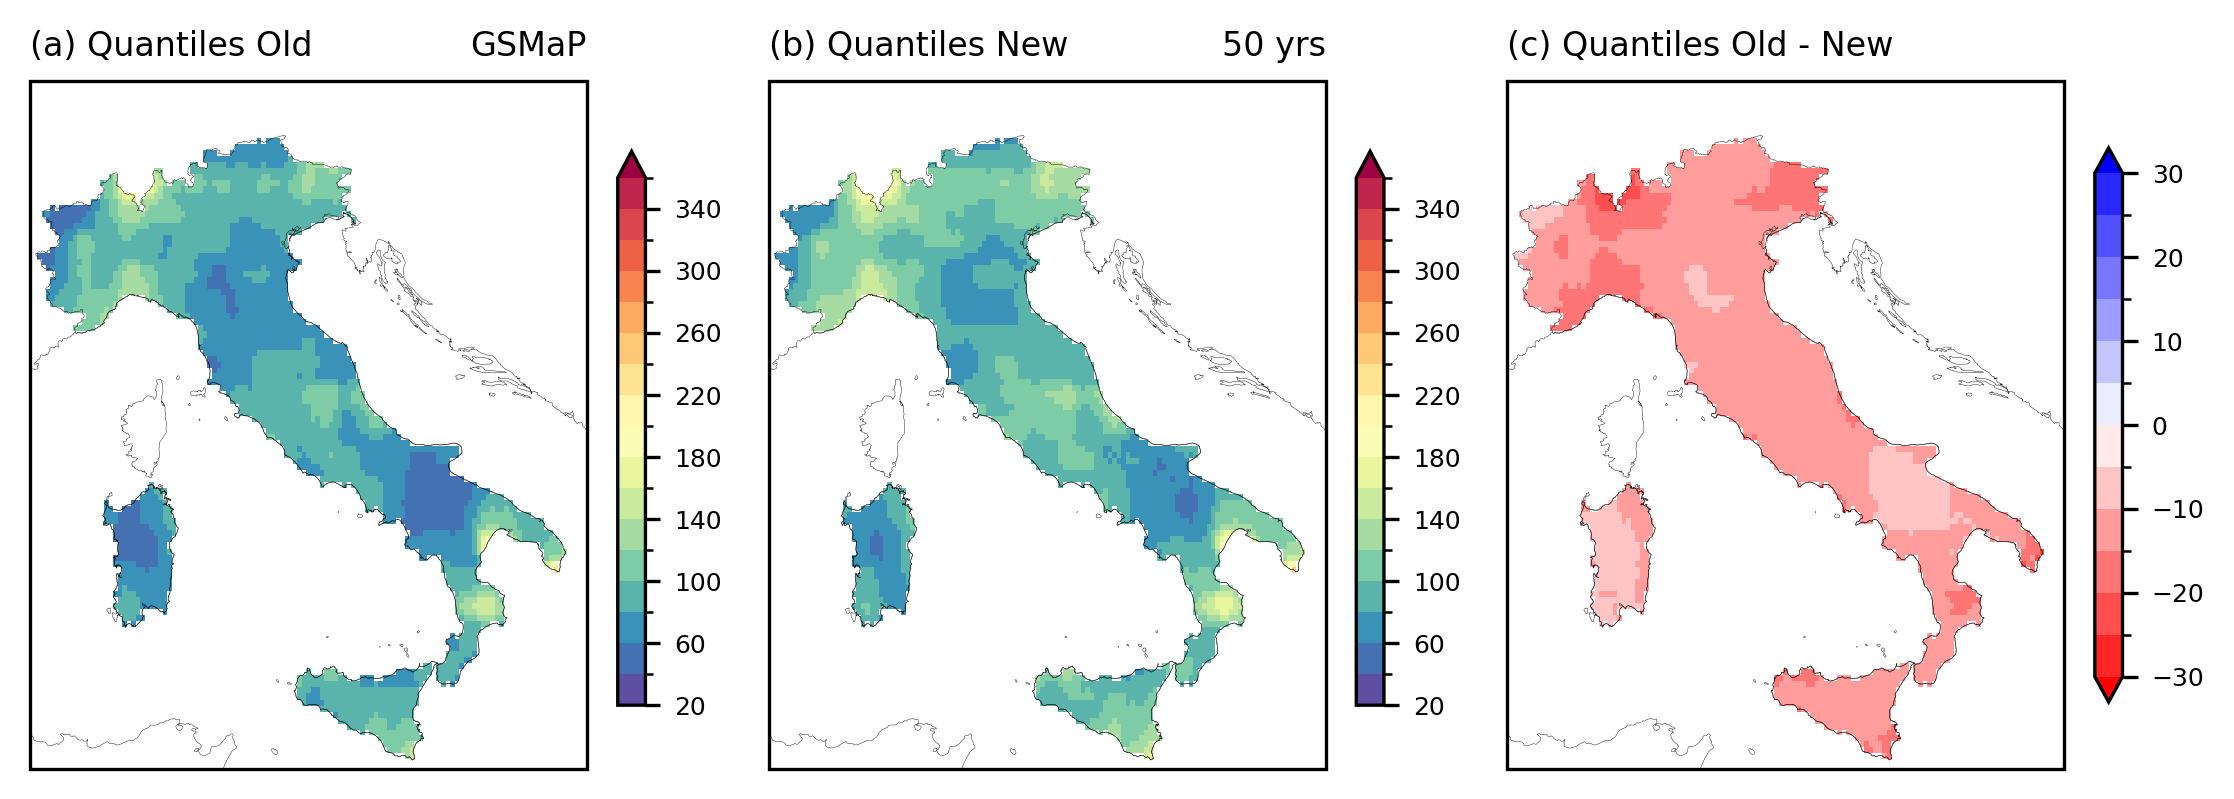

In [21]:
pos = 3

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(9,3),dpi=300)
gs = gridspec.GridSpec(1,3)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, DOWN_xr['Mev_s'][pos,:,:], norm=MEVD_norm, cmap=MEVD_cmap)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(a) Quantiles Old', fontsize=8, loc='left')
ax1.set_title(product, fontsize=8, loc='right')

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, DOWN_xr['Mev_d'][pos,:,:], norm=MEVD_norm, cmap=MEVD_cmap)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(b) Quantiles New', fontsize=8, loc='left')
ax1.set_title('50 yrs', fontsize=8, loc='right')

# ========================================================================================================
ax1 = plt.subplot(gs[0, 2], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, DOWN_xr['Mev_s'][pos,:,:] - DOWN_xr['Mev_d'][pos,:,:], norm=DIFF_norm, cmap=DIFF_cmap)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(c) Quantiles Old - New', fontsize=8, loc='left')

In [22]:
dir_out = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','2_MEV')
dir_file = os.path.join(dir_out,'uncorrected','quantiles_v2',f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_{npix}_thr_1_acf_mar_genetic_pearson.nc')
print(f'Export Data to {dir_file}')
# DOWN_xr.to_netcdf(dir_file)

Export Data to /media/arturo/T9/Data/Italy/Satellite/2_MEV/uncorrected/quantiles_v2/ITALY_DOWN_GSMaP_3h_2002_2023_npix_3_thr_1_acf_mar_genetic_pearson.nc
